<a href="https://colab.research.google.com/github/lucasferrara015/Portafolio-Data-Analysis/blob/main/An%C3%A1lisis_de_Misiones_Espaciales.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Cargar el dataset
df_space = pd.read_csv('mission_launches.csv')

# 2. Limpieza rápida de la columna Date (Extraemos la fecha ignorando zonas horarias complejas)
df_space['Date_Clean'] = pd.to_datetime(df_space['Date'], utc=True, errors='coerce')

# 3. Extraer variables temporales clave
df_space['Year'] = df_space['Date_Clean'].dt.year
df_space['Month'] = df_space['Date_Clean'].dt.month_name()

# 4. Limpiar la columna Price (quitar espacios, comas y convertir a float)
df_space['Price_Clean'] = df_space['Price'].astype(str).str.replace(',', '').str.strip()
df_space['Price_Clean'] = pd.to_numeric(df_space['Price_Clean'], errors='coerce')

# Eliminamos filas donde el año sea nulo debido a errores de lectura
df_space = df_space.dropna(subset=['Year'])
df_space['Year'] = df_space['Year'].astype(int)

print("Dataset preparado para el análisis. Columnas temporales y de precios listas.")

Dataset preparado para el análisis. Columnas temporales y de precios listas.


In [2]:
# ¿Cuántos lanzamientos se realizaron por año?
launches_per_year = df_space['Year'].value_counts().sort_index()

# ¿Qué organización lanzó más misiones en un año determinado?
# Agrupamos por año y organización para contar, luego extraemos el máximo por año
org_per_year = df_space.groupby(['Year', 'Organisation']).size().reset_index(name='Launches')
leader_per_year = org_per_year.loc[org_per_year.groupby('Year')['Launches'].idxmax()]

print("--- TOP 5 AÑOS CON MÁS LANZAMIENTOS ---")
print(launches_per_year.sort_values(ascending=False).head(5))

print("\n--- LÍDERES POR AÑO (Muestra de los últimos 5 años registrados) ---")
print(leader_per_year.tail(5))

--- TOP 5 AÑOS CON MÁS LANZAMIENTOS ---
Year
2018    117
1971    116
1975    112
1976    109
1977    109
Name: count, dtype: int64

--- LÍDERES POR AÑO (Muestra de los últimos 5 años registrados) ---
     Year Organisation  Launches
554  2016         CASC        22
580  2017       SpaceX        18
585  2018         CASC        37
601  2019         CASC        27
618  2020         CASC        19


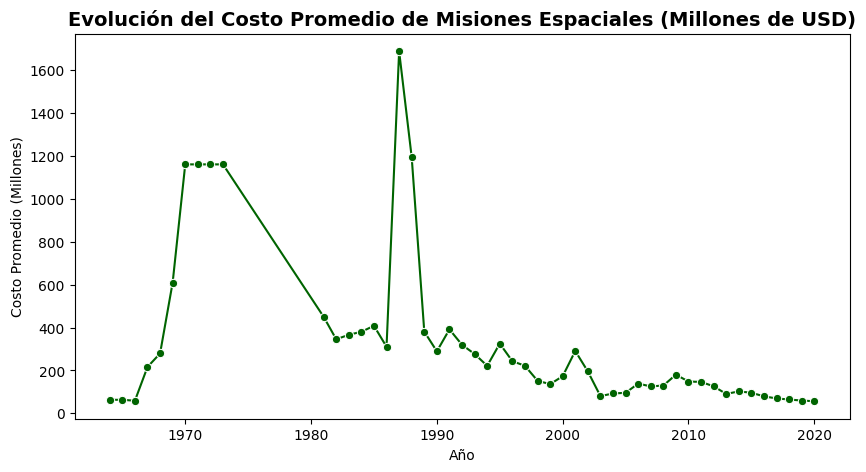

In [3]:
# Agrupar por año y calcular el costo promedio
cost_evolution = df_space.groupby('Year')['Price_Clean'].mean().dropna()

plt.figure(figsize=(10, 5))
sns.lineplot(x=cost_evolution.index, y=cost_evolution.values, marker="o", color="darkgreen")
plt.title('Evolución del Costo Promedio de Misiones Espaciales (Millones de USD)', fontsize=14, fontweight='bold')
plt.xlabel('Año')
plt.ylabel('Costo Promedio (Millones)')
plt.show()

/tmp/ipykernel_6813/1611092899.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_space, x='Month', order=month_order, palette='viridis')


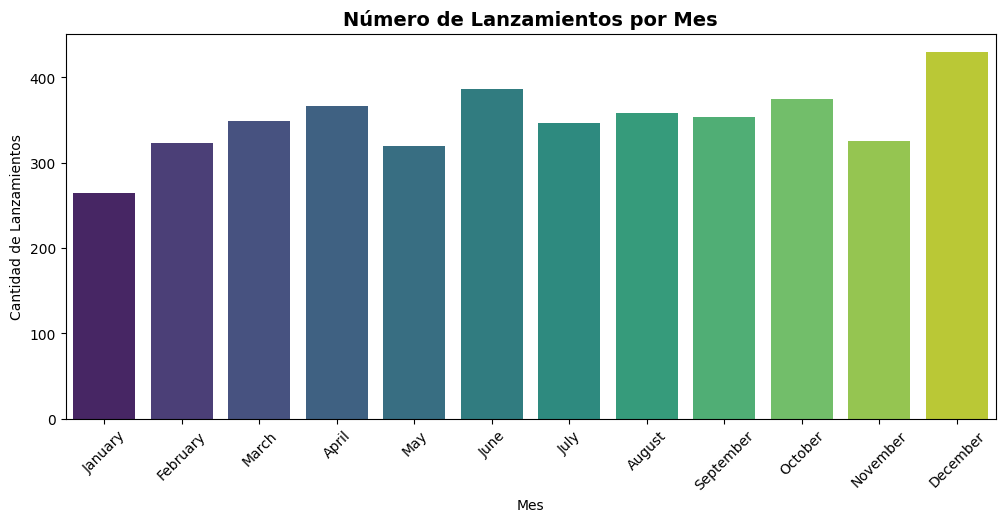

In [4]:
# Orden lógico de los meses para el gráfico
month_order = ['January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October', 'November', 'December']

plt.figure(figsize=(12, 5))
sns.countplot(data=df_space, x='Month', order=month_order, palette='viridis')
plt.title('Número de Lanzamientos por Mes', fontsize=14, fontweight='bold')
plt.xlabel('Mes')
plt.ylabel('Cantidad de Lanzamientos')
plt.xticks(rotation=45)
plt.show()

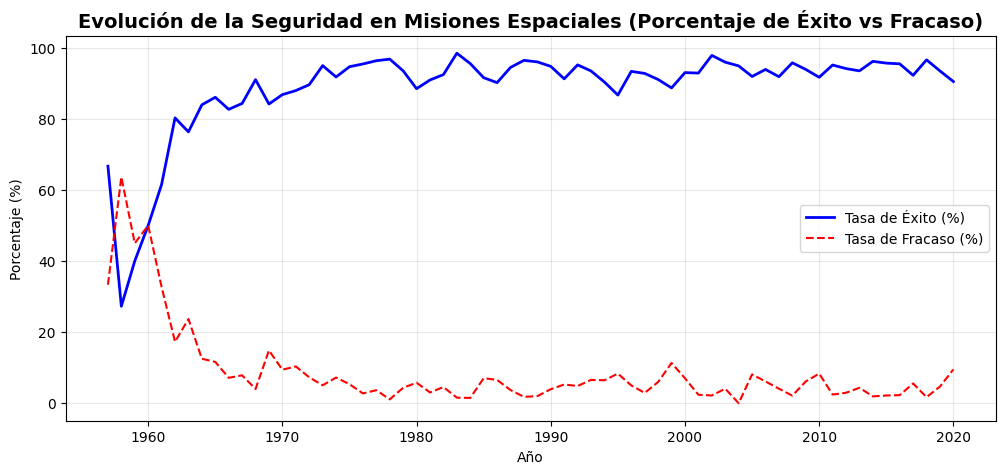

In [5]:
# Crear una tabla cruzada de año vs estado de la misión
safety_trends = pd.crosstab(df_space['Year'], df_space['Mission_Status'], normalize='index') * 100

# Graficar la evolución del porcentaje de éxito
plt.figure(figsize=(12, 5))
plt.plot(safety_trends.index, safety_trends['Success'], label='Tasa de Éxito (%)', color='blue', linewidth=2)
if 'Failure' in safety_trends.columns:
    plt.plot(safety_trends.index, safety_trends['Failure'], label='Tasa de Fracaso (%)', color='red', linestyle='--')

plt.title('Evolución de la Seguridad en Misiones Espaciales (Porcentaje de Éxito vs Fracaso)', fontsize=14, fontweight='bold')
plt.xlabel('Año')
plt.ylabel('Porcentaje (%)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()